# Orthogonalization Methods in Pair Natural Orbital Optimization: A Comparative Study

## Table of Contents

1. Introduction
2. Theory: Orthogonalization Methods
   - Cholesky
   - Symmetric (Löwdin)
   - Mixed
3. Implementation
   - Experiment 1: Standard PNOs
   - Experiment 2: Incremental Orbital Optimization
4. References

---

## 1. Introduction

In quantum calculations, maintaining the orthonormality of orbitals during optimization is a fundamental requirement. This tutorial explores and compares three orthogonalization strategies: The Symmetric (Löwdin) method, the Cholesky decomposition, and a Mixed approach. By applying these methods to the generation of Pair Natural Orbitals, we will examine their respective impacts on symmetry preservation and overall energy convergence.

## 2. Theory: Orthogonalization Methods

### Cholesky Orthogonalization
Cholesky orthogonalization is a matrix-based equivalent to the **Gram-Schmidt process**. It is computationally efficient but treats basis functions asymmetrically.

#### Prerequisites
The overlap matrix $\mathbf{S}$ (where $S_{ij} = \langle \phi_i | \phi_j \rangle$) must satisfy:
1.  **Hermiticity**: $\mathbf{S} = \mathbf{S}^\dagger$ (or $\mathbf{S} = \mathbf{S}^T$ for real orbitals).
2.  **Positive Definiteness**: No linear dependencies (all eigenvalues $> 0$).

> **Note on Stability**: If orbitals become near-identical (e.g., during RDM-based mixing), $\mathbf{S}$ becomes singular ($\det(\mathbf{S}) \to 0$), causing the decomposition to fail.

#### Structural Characteristics
The use of a triangular transformation matrix creates a **hierarchical mixing** of the ordered basis $[\phi_1, \phi_2, \dots, \phi_k]$:

* **$\psi_1$**: Remains unchanged in shape; only normalized.
* **$\psi_2$**: Orthogonalized against $\psi_1$; contains components of $\phi_1$ and $\phi_2$.
* **$\psi_k$**: Orthogonalized against all preceding $k-1$ orbitals.



**Physical Consequences:**
* **Asymmetry**: Orbitals are not treated equally.
* **Localization/Delocalization**: Early orbitals retain original localization (e.g., core orbitals), while later orbitals "absorb" residuals, often becoming delocalized.
* **Order Sensitivity**: The resulting basis depends strictly on the input sequence; permutations yield physically different orbitals.

#### Mathematical Background
$\mathbf{S}$ is factorized into a lower triangular matrix $\mathbf{L}$:
$$\mathbf{S} = \mathbf{L} \mathbf{L}^\dagger$$
The transformation matrix $\mathbf{X}$ is then:
$$\mathbf{X} = (\mathbf{L}^{-1})^\dagger$$
Since $\mathbf{L}^{-1}$ is also triangular, the mixing remains unidirectional.

---

### Symmetric (Löwdin) Orthogonalization
Löwdin orthogonalization utilizes a holistic approach to ensure the orthonormal basis $\psi$ deviates minimally from the original basis $\phi$.

#### Structural Characteristics
* **Principle of Least Change**: It minimizes the sum of squared deviations: $\min \sum_i \left\| \psi_i - \phi_i \right\|^2$.
* **Symmetric Treatment**: Unlike the "fixed-anchor" approach of Cholesky, Löwdin adjusts all vectors equally to achieve orthogonality.
* **Symmetry Preservation**: It maintains the spatial symmetry properties (e.g., $s, p, d$ character) of the original orbitals.
* **Localization**: Orbitals remain centered on their original atoms, developing only minor "tails" on neighbors to satisfy orthogonality.



#### Mathematical Background
The transformation matrix $\mathbf{X}$ is defined by the inverse square root of $\mathbf{S}$:
$$\mathbf{X} = \mathbf{S}^{-1/2}$$
This is typically computed via **Eigenvalue Decomposition (EVD)**:
1.  **Diagonalize**: $\mathbf{S} = \mathbf{U} \mathbf{\Lambda} \mathbf{U}^\dagger$
2.  **Invert Roots**: Compute $\mathbf{\Lambda}^{-1/2}$ (reciprocal square roots of eigenvalues).
3.  **Reconstruct**: $\mathbf{S}^{-1/2} = \mathbf{U} \mathbf{\Lambda}^{-1/2} \mathbf{U}^\dagger$

---

### Mixed Orthogonalization
To balance stability and symmetry, our implementation follows a hybrid workflow:

1.  **Grouping**: Orbitals are grouped by occupation number (degeneracy).
2.  **Intra-group**: **Symmetric (Löwdin)** orthogonalization is applied within degenerate sets to preserve physical symmetry.
3.  **Inter-group**: **Cholesky** orthogonalization is used between different groups.

**Key Benefits**:
* Maintains local symmetries where physically relevant.
* Provides a stable framework for iterative orbital optimization.

## 3. Implementation

### First Experiment - Standard PNOs
This tutorial implements and compares the three orthogonalization methods for quantum orbital optimization using Pair Natural Orbitals (PNOs). PNOs provide localized, correlation-tailored orbitals that reduce computational costs in high-accuracy calculations. Using the FrayedEnds package with the MADNESS multiresolution framework, we generate PNOs from molecular geometries, apply different orthogonalization strategies, and evaluate their performance via Full Configuration Interaction (FCI). Effectiveness is assessed by computing molecular integrals and comparing resulting ground-state energies.

In [1]:
from time import time
import gc

import numpy as np
import tequila as tq
import frayedends
from pyscf import fci
import matplotlib.pyplot as plt

def run_calculation(ortho_method, config):
    true_start = time()
    print(f"\n{'='*80}")
    print(f"Method: {ortho_method.upper()}")
    print(f"{'='*80}\n")

    geom = config["geometry"].replace("\\n", "\n")
    n_orbitals = config["n_orbitals"]
    units = "angstrom"

    n_electrons = tq.quantumchemistry.ParametersQC(geometry=geom, units=units).total_n_electrons

    world = frayedends.MadWorld3D()

    madpno = frayedends.MadPNO(world, geom, units=units, n_orbitals=n_orbitals)
    orbitals = madpno.get_orbitals()
    print(frayedends.get_function_info(orbitals))

    Vnuc = madpno.get_nuclear_potential()

    integrals = frayedends.Integrals3D(world)

    if ortho_method == "mixed":
        info = frayedends.get_function_info(orbitals)
        for i, orb in enumerate(orbitals):
            orb.occupation = info[i]['occ']

    orbitals = integrals.orthonormalize(orbitals=orbitals, method=ortho_method)

    for i in range(len(orbitals)):
        world.line_plot(f"pnoorb{i}_{ortho_method}.dat", orbitals[i])

    integrals = frayedends.Integrals3D(world)
    G = integrals.compute_two_body_integrals(orbitals, ordering='chem')
    T = integrals.compute_kinetic_integrals(orbitals)
    V = integrals.compute_potential_integrals(orbitals, Vnuc)
    S = integrals.compute_overlap_integrals(orbitals)

    # FCI
    e, fcivec = fci.direct_spin1.kernel(T + V, G.elems, n_orbitals, n_electrons)
    print(f"Energy: {e:+2.8f}")

    del integrals
    del madpno
    del Vnuc

    true_end = time()
    print(f"\nTotal time for {ortho_method}: {true_end - true_start:.2f}s")

    return world, e

### Running the Experiment
The calculations are initialized using two $H_2$ molecules arranged along the z-axis, defined via a geometry string. <br>
We specify a basis size of six orbitals to ensure sufficient degrees of freedom for the PNO-based optimization.

In [10]:
config = {
        "geometry": "H 0.0 0.0 -1.2\\nH 0.0 0.0 1.2\\nH 0.0 0.0 -0.4\\nH 0.0 0.0 0.4",
        "n_orbitals": 6,
    }

world1, energie_symmetric = run_calculation("symmetric", config)
del world1

world2, energie_cholesky = run_calculation("cholesky", config)
del world2

world3, energie_mixed = run_calculation("mixed", config)
del world3


Method: SYMMETRIC

Deleted: nemo1.00000
Deleted: mp2_pair00.00000
Deleted: nemo0.00000
Deleted: N7madness7CoulombIdLm3EE16MacroTaskCoulombE_task.00000
Deleted: rhonemo.00000
Deleted: MacroTaskExchangeRow_task.00000
Deleted: mp2_pair11.00000
Deleted: rho.00000
Deleted: mad.restartdata.00000
Deleted: MacroTaskExchangeRow_task.00017
Deleted: MacroTaskExchangeRow_task.00010
Deleted: MacroTaskExchangeRow_task.00019
Deleted: MacroTaskExchangeRow_task.00021
Deleted: MacroTaskExchangeRow_task.00020
Deleted: MacroTaskExchangeRow_task.00018
Deleted: MacroTaskExchangeRow_task.00011
Deleted: MacroTaskExchangeRow_task.00016
Deleted: MacroTaskExchangeRow_task.00005
Deleted: MacroTaskExchangeRow_task.00002
Deleted: MacroTaskExchangeRow_task.00003
Deleted: MacroTaskExchangeRow_task.00004
Deleted: MacroTaskExchangeRow_task.00013
Deleted: MacroTaskExchangeRow_task.00014
Deleted: MacroTaskExchangeRow_task.00022
Deleted: MacroTaskExchangeRow_task.00025
Deleted: MacroTaskExchangeRow_task.00024
Deleted: Ma

In [3]:
results = [
    ("Symmetric (Löwdin)", energie_symmetric),
    ("Cholesky", energie_cholesky),
    ("Mixed", energie_mixed)
]
results_sorted = sorted(results, key=lambda x: x[1])

for method, energy in results_sorted:
    print(f"{method:20s}: {energy:+2.8f} Ha")
print(f"{'='*80}\n")

Mixed               : -5.09967778 Ha
Cholesky            : -5.09967778 Ha
Symmetric (Löwdin)  : -5.09967717 Ha



### Analysis

The Symmetric (Löwdin) method exhibits a marginal energetic variance compared to the others, which is expected given its holistic "least change" approach that aims to symmetrically preserve the original spatial characteristics of the PNOs. <br>
Notably, the Cholesky and Mixed methods yield completely identical ground-state energies. Because the Mixed approach relies on applying symmetric orthogonalization within degenerate groups and Cholesky between them, this exact match strongly implies that the algorithm defaulted entirely to Cholesky. This happens when no degenerate orbital groups are identified during the initial sorting phase. Consequently, we can deduce that either the specific spatial arrangement of this $H_4$ chain inherently prevented exact degeneracies in the PNO occupation numbers, or the numerical threshold used by the method to define degeneracy was set too strictly (too low) to group near-degenerate orbitals together.

### Second Experiment - PNOs with inkrementell orbitals
In this subsequent experiment, we transition from a static evaluation to a dynamic optimization framework. Instead of processing the entire basis set at once, orbitals are introduced incrementally into the active space one by one.

Once the minimum number of orbitals required to accommodate the electrons is reached, the system enters an iterative optimization loop. For each newly added orbital, a Variational Quantum Eigensolver (VQE) calculates the ground-state energy and extracts the corresponding Reduced Density Matrices (RDMs). These RDMs are then utilized to iteratively update and refine the spatial shapes of the orbitals until the energy converges.

In [4]:
def run_calculation_inkrementell(ortho_method, config):
    print(f"\nMethod: {ortho_method.upper()}")

    geom = config["geometry"].replace("\\n", "\n")
    n_orbitals_config = config["n_orbitals"]
    max_iterations = config["max_iterations"]
    units = "angstrom"

    n_electrons = tq.quantumchemistry.ParametersQC(geometry=geom, units=units).total_n_electrons

    world = frayedends.MadWorld3D()

    madpno = frayedends.MadPNO(world, geom, units=units, n_orbitals=n_orbitals_config)
    all_orbitals = madpno.get_orbitals()

    nuc_repulsion = madpno.get_nuclear_repulsion()
    Vnuc = madpno.get_nuclear_potential()

    integrals = frayedends.Integrals3D(world)

    energies = []
    current = 0.0
    current_orbitals = []

    min_orbitals_needed = (n_electrons + 1) // 2

    if ortho_method == "mixed":
        initial_info = frayedends.get_function_info(all_orbitals)
        for i, orb in enumerate(all_orbitals):
            orb.occupation = initial_info[i]['occ']

    for o in range(n_orbitals_config):
        current_orbitals.append(all_orbitals[o])
        print(f"Orbital {o + 1}/{n_orbitals_config}")

        current_orbitals = integrals.orthonormalize(orbitals=current_orbitals, method=ortho_method)

        if (o + 1) < min_orbitals_needed:
            continue

        for iteration in range(max_iterations):
            integrals = frayedends.Integrals3D(world)
            S = integrals.compute_overlap_integrals(current_orbitals)
            G = integrals.compute_two_body_integrals(current_orbitals, ordering='chem')
            T = integrals.compute_kinetic_integrals(current_orbitals)
            V = integrals.compute_potential_integrals(current_orbitals, Vnuc)

            vqe_start = time()
            mol = tq.Molecule(geometry=geom, units="angstrom",
                            one_body_integrals=T + V,
                            two_body_integrals=G,
                            nuclear_repulsion=nuc_repulsion)

            edges = madpno.get_spa_edges()

            U = mol.make_ansatz(name="SPA", edges=edges)
            H = mol.make_hamiltonian()
            E_vqe = tq.ExpectationValue(U, H)
            result = tq.minimize(E_vqe, silent=True)
            vqe_end = time()

            print(f"  Iteration {iteration}: E = {result.energy:+2.8f} (VQE: {vqe_end - vqe_start:.2f}s)")

            e = result.energy
            energies.append(e)

            rdm1, rdm2 = mol.compute_rdms(U=U, variables=result.variables)

            opti = frayedends.Optimization3D(world, Vnuc, nuc_repulsion=nuc_repulsion)
            opti.set_orthogonalization_method(ortho_method)
            current_orbitals = opti.get_orbitals(
                orbitals=current_orbitals, rdm1=rdm1, rdm2=rdm2,
                opt_thresh=0.001, occ_thresh=0.001
            )

            if iteration > 0 and np.isclose(e, current, atol=1e-8, rtol=0.0):
                print(f"  Converged after {iteration + 1} iterations")
                break
            current = e

    del integrals
    del madpno
    del Vnuc
    del all_orbitals
    del current_orbitals
    gc.collect()
    return world, energies

### Running the Experiment
The selected geometry features intentionally short distances between the hydrogen pairs. As verified in previous experiments, this compact arrangement  induces a higher degree of linear dependency among the spatial orbitals. <br>
**Computational Note**: Executing this full optimization sequence can take up to an hour. If you prefer a faster runtime for testing purposes, you can reduce the number of active orbitals (n_orbitals) or the maximum VQE iterations (max_iterations). Please note that doing so will reduce the resolution of the convergence behavior and yield less definitive results.

In [8]:
config = {
    "geometry": "H 0.0 0.0 -0.4\\nH 0.0 0.0 0.4\\nH 0.0 0.0 -0.8\\nH 0.0 0.0 0.8",
    "n_orbitals": 6,
    "max_iterations": 10,
}


world1, energies_symmetric = run_calculation_inkrementell("symmetric", config)
del world1

world2, energies_cholesky = run_calculation_inkrementell("cholesky", config)
del world2

world3, energies_mixed = run_calculation_inkrementell("mixed", config)
del world3


all_energies = {
    "symmetric": energies_symmetric,
    "cholesky": energies_cholesky,
    "mixed": energies_mixed
}


Method: SYMMETRIC
Deleted: nemo1.00000
Deleted: mp2_pair00.00000
Deleted: nemo0.00000
Deleted: N7madness7CoulombIdLm3EE16MacroTaskCoulombE_task.00000
Deleted: rhonemo.00000
Deleted: MacroTaskExchangeRow_task.00000
Deleted: mp2_pair11.00000
Deleted: rho.00000
Deleted: mad.restartdata.00000
Deleted: MacroTaskExchangeRow_task.00017
Deleted: MacroTaskExchangeRow_task.00010
Deleted: MacroTaskExchangeRow_task.00019
Deleted: MacroTaskExchangeRow_task.00021
Deleted: MacroTaskExchangeRow_task.00020
Deleted: MacroTaskExchangeRow_task.00018
Deleted: MacroTaskExchangeRow_task.00011
Deleted: MacroTaskExchangeRow_task.00016
Deleted: MacroTaskExchangeRow_task.00005
Deleted: MacroTaskExchangeRow_task.00002
Deleted: MacroTaskExchangeRow_task.00003
Deleted: MacroTaskExchangeRow_task.00004
Deleted: MacroTaskExchangeRow_task.00013
Deleted: MacroTaskExchangeRow_task.00014
Deleted: MacroTaskExchangeRow_task.00022
Deleted: MacroTaskExchangeRow_task.00025
Deleted: MacroTaskExchangeRow_task.00024
Deleted: Mac

### Plotting
This code generates a Plot of the energy convergence of the experiment

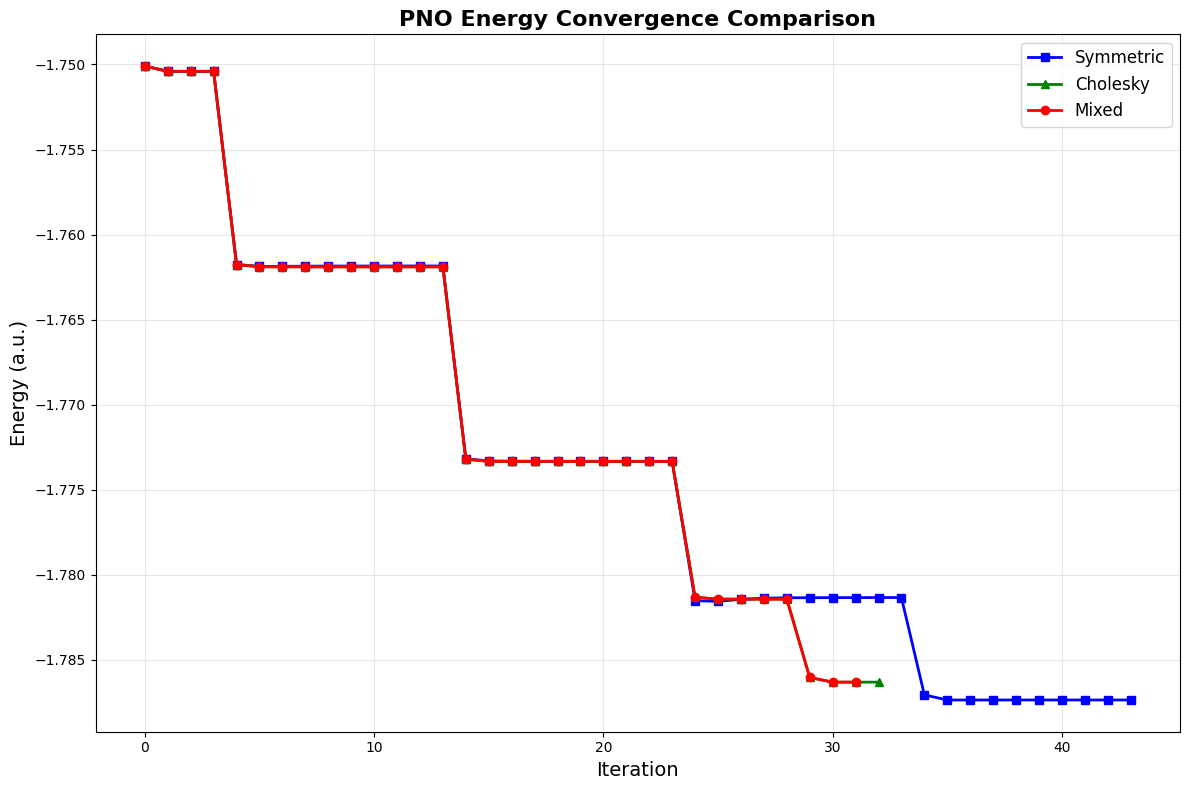

In [9]:
colors = {'symmetric': 'blue', 'cholesky': 'green', 'mixed': 'red'}
markers = {'symmetric': 's', 'cholesky': '^', 'mixed': 'o'}
plt.figure(figsize=(12, 8))

for method_name, energies in all_energies.items():
    color = colors.get(method_name, 'black')
    marker = markers.get(method_name, 'x')
    plt.plot(range(len(energies)), energies,
            marker=marker, color=color, linewidth=2, markersize=6,
            label=method_name.capitalize())

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Energy (Hartree)', fontsize=14)
plt.title('PNO Energy Convergence Comparison', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis
The convergence plot shows how the systems energy drops as orbitals are added one by one to the active space. Each sharp decrease in energy marks the addition of a new orbital, while the flat plateaus show the VQE refining those orbitals. <br>
A clear difference in performance exists between the methods. The Cholesky and Mixed strategies converge very efficiently, reaching the ground-state energy by iterations 31 (mixed) and 32 (cholesky). Their identical paths prove that the Mixed method relied entirely on the Cholesky routine since no degenerate groups were detected. In contrast, the Symmetric approach is much slower, requiring 43 iterations to fully converge.This speed difference is caused by the compact $H_4$ geometry. In such a tight arrangement, the atoms create strong linear dependencies. <br>
The Cholesky method handles this well because it keeps previously optimized orbitals fixed and only adjusts the newest one, providing a stable starting point for the VQE. However, the Symmetric method attempts to shift all orbitals equally every time a new one is added. In a crowded atomic system, this constant global readjustment creates more work for the optimizer and significantly slows down the process.

## References

1. Langkabel, F., Knecht, S. & Kottmann, J. S. (2024). "The advent of fully variational quantum eigensolvers using a hybrid multiresolution approach". arXiv preprint (oder entsprechendes Journal, falls bekannt).
2. Szabo, A. & Ostlund, N. S. (1996). Modern Quantum Chemistry: Introduction to Advanced Electronic Structure Theory. Dover Publications, Mineola, N. Y.
